# TP4 - Aposteriori errors

In [ ]:
#Install package
import sys
!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install scikit-fem

In [4]:
# import packages

import skfem  # for Finite Element Method
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import random

 ============================================================
 
## POD-Galerkin with FEM
### 2) Poisson equation  / thermal stationary conduction

 Elliptic diffusion problem (2D) with scikit-fem:
 
   $ -\nabla \cdot ( A(x,\mu) \nabla u) = g(x)  \ \mathrm{ on }\ (0, 1)^2$ 
   
$    u(0) = u(1) = 0  (Dirichlet)$

    -------------------
    
    FEM:
 
 Find $u_h = \sum_{i=1}^{\mathcal{N}} u_i w_i$ such that :

   $a(u_h,v_h;\mu)=l(v_h) \forall v_h \in V_h$

 with Dirichlet boundary $u=0$ on $\partial \Omega$.

 Here $\Omega=[0,1] \times [0,1] = \Omega_1 \cup \Omega_2$. We use a uniform Delaunay mesh, with $Nx \times Ny$ degrees of freedom.
 
$A(x,\mu)= \mu $  in $ \Omega_1$, and $1 $ in $ \Omega_2$

$\mu \in [0,10]$ 

$\Omega_1=[0,1/2[$

$g=1$

--------
Solve the problem for $\mu_1 = 0.5$ and $\mu_2 = 1.5$

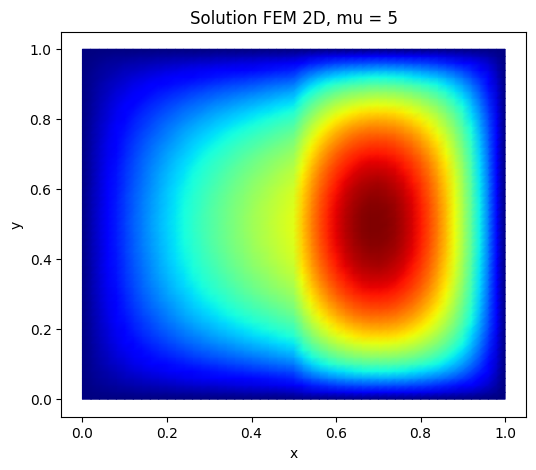

In [1]:
"""
Elliptic diffusion problem (2D) with scikit-fem:

$ -\nabla \cdot ( A(x,\mu) \nabla u) = g(x)  \ \mathrm{ on }\ (0, 1)^2$ 
$    u(0) = u(1) = 0  (Dirichlet)$

$\Omega_1=[0,1/2[$
"""

import numpy as np
import matplotlib.pyplot as plt

from skfem import MeshTri, Basis, asm, enforce,solve
from skfem.element import ElementTriP1
from skfem.helpers import dot, grad
from skfem.assembly import BilinearForm, LinearForm
from skfem import solve

# -----------------------
# Problem setup
# -----------------------

Nx = 50
Ny = 50

# Maillage triangulaire du carré (0,1)^2
m = MeshTri.init_tensor(
    np.linspace(0.0, 1.0, Nx + 1),
    np.linspace(0.0, 1.0, Ny + 1)
)

basis = Basis(m, ElementTriP1())
# Dirichlet boundary DOFs 
D = basis.get_dofs().all()  # all dofs

# -----------------------
# Diffusion coefficient a(x, mu)
# Omega_1 = {x < 0.5}, Omega_2 = {x >= 0.5}
# -----------------------
def A_piecewise(x, mu):
    return ...

# -----------------------
# RHS: g = 1
# -----------------------
@LinearForm
def rhs(v, w):
    return ...

# -----------------------
# Bilinear form
# -----------------------
# Global a(u,v)
@BilinearForm
def diffusion(u, v, w):
    #x = w.x[0]
    return ...
    
@BilinearForm
def diffusion_1(u, v, w):
    # contribution on Omega_1 = {x < 0.5}
    ...
    return ...


@BilinearForm
def diffusion_2(u, v, w):
    # contribution on Omega_2 = {x >= 0.5}
    ...
    return ...


# -----------------------
# Assembly
# -----------------------
def FEMassembling(m):
    basis = ...
    #Instead of global which depend on mu
    A1 = ...# on Omega_1
    A2 = ...   # on Omega_2
    b =...# g = 1
    return A1,A2, b, basis


# -----------------------
# Solve
# -----------------------
def FEMsolve(A1, A2, b, basis, mu):
    A =...
    A_bc, b_bc = ...# enforce boundary condition
    u = ...# solve
    return u



# -----------------------
# Example
# -----------------------
mu =5
A1,A2, b, basis = FEMassembling(m)
u = FEMsolve(A1, A2, b, basis, mu)


# -----------------------
# Plot
# -----------------------
fig, ax = plt.subplots(figsize=(6, 5))
m.plot(u, ax=ax, shading='gouraud')
ax.set_title(f"Solution FEM 2D, mu = {mu}")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

In [2]:
""" POD """

print("-----------------------------------")
print("        Offline                    ")
print("-----------------------------------")

def Construct_RB(NumberOfSnapshots=100,NumberOfModes=20,m=m):
    
    print("number of modes: ",NumberOfModes)
    basis = ...

    A1,A2, b, basis= ...
  
    Snapshots=[]
    for i in range(NumberOfSnapshots):
        mu = ... #random coefficient in [0, 1] 
        U =...
        Snapshots.append(U)
       
    #print("last parameter:",mu)

    ## SVD ##

    # on (u,v)_L2
    @BilinearForm
    def massVelocity(u, v, _):
        return u * v
    L2=massVelocity.assemble(basis)
    
    # same as TP3!
    ...
    # same as TP3!
    
    ReducedBasis = ...

    return ReducedBasis

-----------------------------------
        Offline                    
-----------------------------------


number of modes:  6
last parameter: 8.403452591188444
eigenvalues:  [4.79140306e-02 1.76946984e-03 9.73351664e-06 1.32488904e-17
 1.08639221e-17 8.56048622e-18]
Relativ Information Content (must be close to 0):  -6.661338147750939e-16


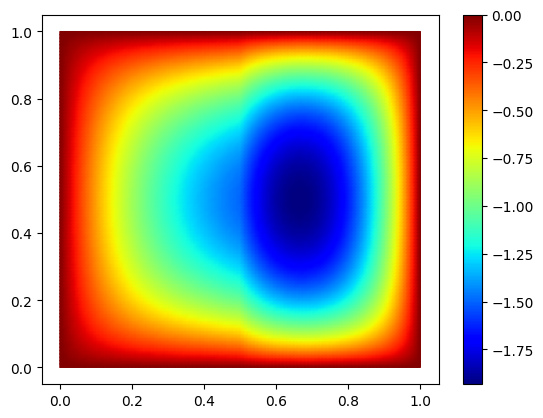

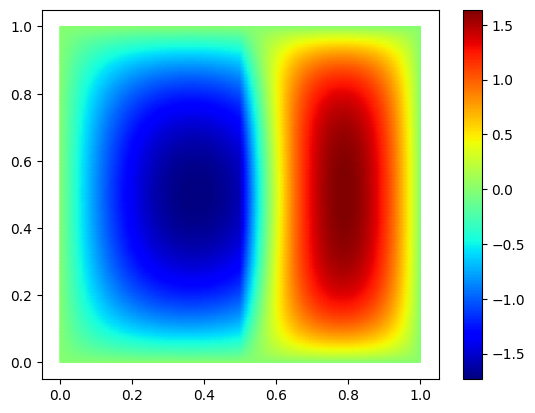

In [5]:
## TEST 
Nx=Ny = 100
m = MeshTri.init_tensor(
    np.linspace(0.0, 1.0, Nx + 1),
    np.linspace(0.0, 1.0, Ny + 1)
)
basis = Basis(m, ElementTriP1())
Phi=Construct_RB(NumberOfSnapshots=100,NumberOfModes=6,m=m)
ReducedBasis=Phi.T              

fig, ax = plt.subplots()

im=m.plot(ReducedBasis[:,0], ax=ax, shading='gouraud',colorbar=True)
fig, ax = plt.subplots()

m.plot(ReducedBasis[:,1], ax=ax, shading='gouraud',colorbar=True)


plt.show()

In [6]:
# POD-Galerkin

# assemble full system
A1,A2, b, basis=...

def solve_fem_rom(A1,A2,b,mu, Phi,m):
    ...

    return a, u_rom


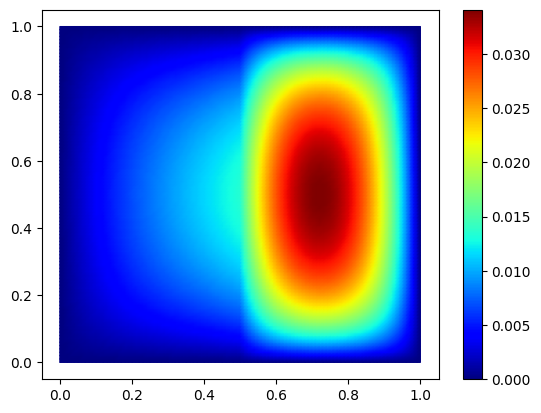

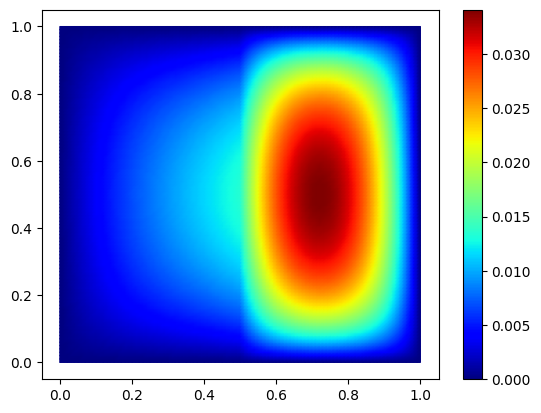

In [12]:
### show projection of u on VN

mu = 10
Nx=Ny = 100
m = MeshTri.init_tensor(
    np.linspace(0.0, 1.0, Nx + 1),
    np.linspace(0.0, 1.0, Ny + 1)
)
basis = Basis(m, ElementTriP1())
A1,A2, b, basis= FEMassembling(m)
a,u_proj=...

fig, ax = plt.subplots()

m.plot(u_proj, ax=ax, shading='gouraud',colorbar=True)

## Compare with u 
u=...

fig, ax = plt.subplots()

m.plot(u, ax=ax, shading='gouraud',colorbar=True)

plt.show()

n 20
number of modes:  5
last parameter: 7.509781052332557
eigenvalues:  [2.40318666e-02 9.25788586e-04 7.06303709e-06 5.36373774e-18
 4.61701375e-18]
Relativ Information Content (must be close to 0):  -2.220446049250313e-16
0.00011138323800678854
n 30
number of modes:  5
last parameter: 5.480878231061106
eigenvalues:  [2.22299945e-02 6.84554478e-04 6.71423146e-06 4.39904411e-18
 2.97561363e-18]
Relativ Information Content (must be close to 0):  -2.220446049250313e-16
4.85323469705371e-05
n 40
number of modes:  5
last parameter: 9.868641468140527
eigenvalues:  [2.32851556e-02 9.13440665e-04 6.65241698e-06 5.56358835e-18
 4.45544105e-18]
Relativ Information Content (must be close to 0):  -4.440892098500626e-16
2.6353402541545168e-05
n 50
number of modes:  5
last parameter: 5.445511126420616
eigenvalues:  [2.66753732e-02 7.63038252e-04 6.82928888e-06 6.29313835e-18
 5.29522154e-18]
Relativ Information Content (must be close to 0):  -1.1102230246251565e-15
1.7590322257836863e-05
n 70
numb

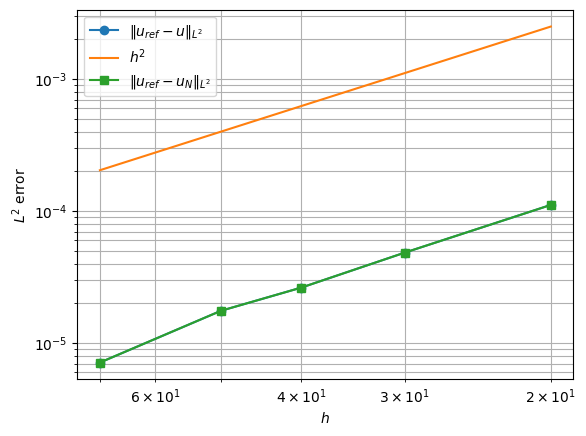

In [13]:
#### Convergence
mu = 0.6

err_true=[]
err_rom=[]

m_ref = MeshTri.init_tensor(
    np.linspace(0.0, 1.0, 250 + 1),
    np.linspace(0.0, 1.0, 250 + 1)
)

A1_ref, A2_ref, b_ref, basis_ref = ...
U_ref = ...


# True solution = refined solution
u_ref_interp = basis_ref.interpolator(U_ref)

# for L2 norm
@BilinearForm
def massVelocity(u, v, _):
    return u * v

# choose grid sizes to test
Ns = [...]  # adapt as you want
for n in Ns:
    print("n",n)
    m = ...
    basis = ...

    A1, A2, b, basis = ...
    U = ...
 
    Phi=...

    _,Uproj=...

    
    # Refined solution interpolated on mesh m
    X = basis.doflocs              # shape = (2, ndof)
    U_ref_on_mesh = u_ref_interp(X)

    ## print error
    L2=massVelocity.assemble(basis)
    
    true_error =...
    l2_true_error=...
    
    rom_error = ...
    l2_rom_error=...


   # L2 errors 
    err_true.append(l2_true_error)
    err_rom.append(l2_rom_error)

# ---------------------------
# Plot log-log convergence
# ---------------------------
hs = np.array(Ns)
err_true = np.array(err_true)
err_rom = np.array(err_rom)

plt.figure()
plt.loglog(hs, err_true, "o-", label=r"$\|u_{ref}-u\|_{L^2}$")
plt.loglog(hs, 1/(hs**2), "-", label=r"$h^2$")
plt.loglog(hs, err_rom, "s-", label=r"$\|u_{ref}-u_N\|_{L^2}$")
plt.gca().invert_xaxis()  # optional: smaller h to the right
plt.xlabel(r"$h$")
plt.ylabel(r"$L^2$ error")
plt.grid(True, which="both")
plt.legend()
plt.show()


## Aposteriori ##
$\|r_N\|_V^2 =r^T M_V^{-1} r$ where $M_V=A1+A2= A$

In [14]:
from scipy.sparse.linalg import spsolve

def alpha_LB(mu):
    """
    Lower bound of a
    """
    return ...


def get_interior_dofs(basis):
    """
    Interior DDL ( since test functions in H^1_0)
    """
    D = basis.get_dofs().all()
    I = np.setdiff1d(np.arange(basis.N), D)
    return D, I


def RB_solve_certified(Phi, A1, A2, F, basis, mu):
   
    D, I = get_interior_dofs(basis)

    # Full matrices
    A = ...
    X = ...   # Matrix for the norm ||.||_X

    # Interior DDL restriction
    A_I = A[I][:, I]
    X_I = X[I][:, I]
    F_I = F[I]

    # Restricted reduced basis
    Phi_I = Phi[:,I]
    ReducedBasis_I=Phi_I.T
    # Reduce system
    
    A_rb = ...
    F_rb = ...

    coeff = ...

    # ROM reconstructed
    u_rb_I = ...
    u_rb = np.zeros(basis.N) # 0 at the boundary 
    u_rb[I] = u_rb_I

    # Interior residual
    r_I = ...

    # Dual norm of the residual : sqrt(r^T X^{-1} r)
    z = ...
    dual_norm = ...

    # Estimateur certifié
    Delta_N = ...

    return u_rb, coeff, dual_norm, Delta_N

In [15]:
def true_error_X_norm(U_fem, U_rb, A1, A2, basis):
    """
    Error with 
    X = A1 + A2.
    """
    D, I = get_interior_dofs(basis)
    X = A1 + A2
    X_I = X[I][:, I]

    e_I = ...
    err_X = ...
    return err_X

In [ ]:
mu = 0.6
## test with N=2 and 3 reduced basis functions

err_true_L2 = []
err_rom_L2 = []

err_true_X = []
estimator = []
effectivity = []

hs = []

# -------------------------------------------------
# Solution de référence sur maillage fin
# -------------------------------------------------
Nref = 300
m_ref = MeshTri.init_tensor(
    np.linspace(0.0, 1.0, Nref + 1),
    np.linspace(0.0, 1.0, Nref + 1)
)

A1_ref, A2_ref, F_ref, basis_ref = FEMassembling(m_ref)
U_ref = FEMsolve(A1_ref, A2_ref, F_ref, basis_ref, mu)
u_ref_interp = basis_ref.interpolator(U_ref)
    
@BilinearForm
def StiffnessMat(u, v, _):
    return dot(grad(u), grad(v))

M=StiffnessMat.assemble(basis_ref)

# interpolateur de la solution grossière vers le maillage fin
Xref = basis_ref.doflocs
x = Xref[0]
y = Xref[1]

tol = 1e-12
interior = (
        (x > tol) & (x < 1.0 - tol) &
        (y > tol) & (y < 1.0 - tol)
)

# -------------------------------------------------
# Boucle de convergence
# -------------------------------------------------
Ns = [10, 20, 30, 40, 60]

for n in Ns:
    print("n =", n)

    m = ...

    # reduced basis
    Phi = ...

    # FEM + ROM + certification
    
    A1, A2, F, basis = ...
    U = ...

    # ROM + certification
    U_rb, coeff, dual_norm, Delta_N = ...

    #Interpolated FEM on refined mesh
    Xdof = basis.doflocs

    u_h_interp = basis.interpolator(U)
    U_on_ref = np.zeros(basis_ref.N)
    U_on_ref[interior] = u_h_interp(Xref[:, interior])

    u_rb_interp = basis.interpolator(U_rb)
    U_rb_on_ref = np.zeros(basis_ref.N)
    U_rb_on_ref[interior] = u_rb_interp(Xref[:, interior])

    e_true_ref = ...
    true_error =...
   
    e_rom_ref = ...
    rom_error = ...


    err_true_L2.append(true_error)
    err_rom_L2.append(rom_error)

    # -------------------------
    # True error in X norm
    # -------------------------
    err_X = true_error_X_norm(U, U_rb, A1, A2, basis)

    
    err_true_X.append(err_X)
    estimator.append(Delta_N)

    eff = Delta_N / err_X if err_X > 1e-14 else np.nan
    effectivity.append(eff)

    print(f"  ||u_ref - u_h||_L2 = {l2_true_error:.3e}")
    print(f"  ||u_ref - u_N||_L2 = {l2_rom_error:.3e}")
    print(f"  ||u_h - u_N||_X    = {err_X:.3e}")
    print(f"  ||r_N||_X'         = {dual_norm:.3e}")
    print(f"  Delta_N(mu)        = {Delta_N:.3e}")
    print(f"  effectivity        = {eff:.3e}")

In [ ]:

hs = np.array(hs)

err_true_L2 = np.array(err_true_L2)
err_rom_L2 = np.array(err_rom_L2)

plt.figure(figsize=(7, 5))
plt.loglog(hs, err_true_L2, "o-", label=r"$\|u_{ref}-u_h\|_{L^2}$")
plt.loglog(hs, hs, "--", label=r"$h^2$")
plt.loglog(hs, err_rom_L2, "s-", label=r"$\|u_{ref}-u_N\|_{L^2}$")

plt.gca().invert_xaxis()
plt.xlabel(r"$h$")
plt.ylabel(r"Error $L^2$")
plt.grid(True, which="both")
plt.legend()
plt.title(" FEM / ROM in $L^2$ norm")
plt.show()

In [ ]:

err_true_X = np.array(err_true_X)
estimator = np.array(estimator)
effectivity = np.array(effectivity)

plt.figure(figsize=(7, 5))
plt.loglog(hs, err_true_X, "o-", label=r"True error $\|u_h-u_N\|_X$")
plt.loglog(hs, estimator, "s--", label=r"Estimator $\Delta_N(\mu)$")

plt.gca().invert_xaxis()
plt.xlabel(r"$h$")
plt.ylabel(r"estimator")
plt.grid(True, which="both")
plt.legend()
plt.title("Certification a posteriori ")
plt.show()

In [ ]:
plt.figure(figsize=(7, 4))
plt.semilogx(hs, effectivity, "o-")
plt.gca().invert_xaxis()
plt.xlabel(r"$h$")
plt.ylabel("Effectivity")
plt.grid(True, which="both")
plt.title(r"Effectivity $\Delta_N / \|u_h-u_N\|_X$")
plt.show()